# Phase 2: Minority Class Optimization with Constrained Generation + Augmentation

**Goal**: Fix hallucination + improve CBB/CGM accuracy + prevent overfitting

**Changes from Phase 1**:
- ✅ Constrained generation (force 5 valid classes)
- ✅ Visual augmentation (aggressive for CBB/CGM)
- ✅ Reduced epochs (2 instead of 3)
- ✅ Lower learning rate (3e-5 instead of 5e-5)
- ✅ More frequent evaluation (every 250 steps)

**Phase 1 Results (FAILED)**:
- CBB: 0% (0/5) → Target: >20%
- CGM: 12.5% (1/8) → Target: >25%
- CMD: 53.6% (collapsed from 97%)
- Overall: 52% (failed from 69.83%)
- **Critical Issue**: Model hallucinated disease names

**Phase 2 Expected Results**:
- No hallucination (all predictions from 5 classes)
- CBB: >20%
- CGM: >25%
- CMD: >85%
- Overall: >60%

## 1. Imports et Configuration

In [1]:
import os
import json
import re
import torch
from pathlib import Path
from PIL import Image
from dataclasses import dataclass
from typing import Dict, List, Any
from datasets import Dataset
from transformers import (
    AutoProcessor,
    TrainingArguments,
    Trainer
)
from tqdm import tqdm

# IMPORTANT: Import unsloth AVANT transformers pour optimisations
from unsloth import FastVisionModel

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Skipping import of cpp extensions due to incompatible torch version 2.9.0+cu128 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
/tmp/ipykernel_894282/529373224.py:18: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch version: 2.9.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
GPU Memory: 33.67 GB


In [2]:
from pathlib import Path

# Chemins
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava/new_implementation")
DATA_DIR = BASE_DIR / "data" / "stage1"
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "stage1_minority_opt_v1"  # Phase 1
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Modèle Gemma 3N
MODEL_NAME = "unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit"
TARGET_IMAGE_SIZE = (512, 512)

# LoRA Configuration
LORA_CONFIG = {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.15,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
}

print(f"\nBase Dir: {BASE_DIR}")
print(f"Checkpoint Dir: {CHECKPOINT_DIR}")
print(f"Model: {MODEL_NAME}")



Base Dir: /home/hounfodjidagba/learning/cassava/new_implementation
Checkpoint Dir: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage1_minority_opt_v1
Model: unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit


## 2. Configuration des Chemins et Paramètres

### Changements clés vs Qwen3-VL:
- **Modèle**: Gemma 3N-E2B-it (2B vs 8B)
- **Learning Rate**: 2e-4 (10x plus élevé !)
- **Batch size**: 4 (vs 1)
- **Grad accumulation**: 2 (vs 8)
- **Époques**: 3 (vs 5)

In [3]:
# =============================================================================
# LOAD PRE-COMPUTED CLASS WEIGHTS FOR MINORITY CLASS OPTIMIZATION
# =============================================================================

import torch

# Load pre-computed class weights
class_weights_path = "/home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.pt"
class_weights = torch.load(class_weights_path)

print("\n" + "="*80)
print("CLASS WEIGHTS FOR MINORITY CLASS OPTIMIZATION")
print("="*80)
print(f"\nClass weights loaded from: {class_weights_path}")
print(f"\nWeight values (higher = more emphasis during training):")
print(f"  CBB (0):     {class_weights[0]:.2f}  ⬆️⬆️⬆️  HIGHEST (most minority class)")
print(f"  CBSD (1):    {class_weights[1]:.2f}")
print(f"  CGM (2):     {class_weights[2]:.2f}  ⬆️⬆️  HIGH (second minority)")
print(f"  CMD (3):     {class_weights[3]:.2f}  ⬇️⬇️  LOWEST (majority class)")
print(f"  Healthy (4): {class_weights[4]:.2f}")
print(f"\nImbalance ratio compensation: {class_weights[0] / class_weights[3]:.1f}:1")
print("="*80)



CLASS WEIGHTS FOR MINORITY CLASS OPTIMIZATION

Class weights loaded from: /home/hounfodjidagba/learning/cassava/outputs/augmentation_weights/class_weights.pt

Weight values (higher = more emphasis during training):
  CBB (0):     5.61  ⬆️⬆️⬆️  HIGHEST (most minority class)
  CBSD (1):    1.18
  CGM (2):     2.56  ⬆️⬆️  HIGH (second minority)
  CMD (3):     0.34  ⬇️⬇️  LOWEST (majority class)
  Healthy (4): 1.65

Imbalance ratio compensation: 16.7:1


In [4]:
# ============================================================
# TRAINING CONFIGURATION - PHASE 2 (OPTIMIZED)
# ============================================================

TRAINING_CONFIG = {
    "output_dir": str(CHECKPOINT_DIR),
    "per_device_train_batch_size": 4,
    "gradient_accumulation_steps": 2,

    # PHASE 2 CHANGES - Reduce overfitting
    "num_train_epochs": 2,          # Reduced from 3
    "learning_rate": 3e-5,          # Reduced from 5e-5
    "warmup_ratio": 0.1,            # Use ratio instead of fixed steps
    "weight_decay": 0.15,           # Increased from 0.1
    "max_grad_norm": 0.3,           # Reduced from 0.5

    "logging_steps": 25,
    "save_steps": 250,              # Reduced from 500 - more frequent saves
    "save_total_limit": 5,
    "eval_strategy": "steps",
    "eval_steps": 250,              # Reduced from 500 - more frequent eval
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "fp16": not torch.cuda.is_bf16_supported(),
    "bf16": torch.cuda.is_bf16_supported(),
    "optim": "adamw_8bit",
    "lr_scheduler_type": "cosine",
    "seed": 42,
    "report_to": "none",
    "remove_unused_columns": False,  # Keep from Phase 1
}

print("="*60)
print("TRAINING CONFIGURATION - PHASE 2")
print("="*60)
print(f"Epochs: {TRAINING_CONFIG['num_train_epochs']} (reduced from 3)")
print(f"Learning rate: {TRAINING_CONFIG['learning_rate']} (reduced from 5e-5)")
print(f"Weight decay: {TRAINING_CONFIG['weight_decay']} (increased from 0.1)")
print(f"Max grad norm: {TRAINING_CONFIG['max_grad_norm']} (reduced from 0.5)")
print(f"Eval steps: {TRAINING_CONFIG['eval_steps']} (reduced from 500)")
print(f"Save steps: {TRAINING_CONFIG['save_steps']} (reduced from 500)")
print("="*60)
print("Changes aim to reduce overfitting and improve generalization")


TRAINING CONFIGURATION - PHASE 2
Epochs: 2 (reduced from 3)
Learning rate: 3e-05 (reduced from 5e-5)
Weight decay: 0.15 (increased from 0.1)
Max grad norm: 0.3 (reduced from 0.5)
Eval steps: 250 (reduced from 500)
Save steps: 250 (reduced from 500)
Changes aim to reduce overfitting and improve generalization


## 3. Chargement du Modèle avec Unsloth

Gemma 3N-E2B-it avec optimisations Unsloth:
- 2B effective parameters (6B total)
- 4-bit quantization
- Gradient checkpointing
- LoRA fine-tuning

In [7]:
# ============================================================
# VALID DISEASE CLASS NAMES (for constrained generation)
# ============================================================

DISEASE_NAMES = [
    "Cassava Bacterial Blight (CBB)",
    "Cassava Brown Streak Disease (CBSD)",
    "Cassava Green Mottle (CGM)",
    "Cassava Mosaic Disease (CMD)",
    "Healthy"
]

print("Valid disease classes for Phase 2:")
for i, disease in enumerate(DISEASE_NAMES):
    print(f"  {i}: {disease}")
print(f"\n✅ {len(DISEASE_NAMES)} classes defined")

Valid disease classes for Phase 2:
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy

✅ 5 classes defined


In [6]:
print("\n" + "="*60)
print("LOADING GEMMA 3N WITH UNSLOTH")
print("="*60)

model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    r=LORA_CONFIG["r"],
    lora_alpha=LORA_CONFIG["lora_alpha"],
    lora_dropout=LORA_CONFIG["lora_dropout"],
    target_modules=LORA_CONFIG["target_modules"],
    use_rslora=True,
    use_gradient_checkpointing="unsloth"
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

print(f"\nModel: {MODEL_NAME}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable %: {100 * sum(p.numel() for p in model.parameters() if p.requires_grad) / sum(p.numel() for p in model.parameters()):.2f}%")
print("="*60)


LOADING GEMMA 3N WITH UNSLOTH


==((====))==  Unsloth 2026.1.1: Fast Gemma3N patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.15.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Making `model.base_model.model.model.language_model` require gradients

Model: unsloth/gemma-3n-E2B-it-unsloth-bnb-4bit
Trainable parameters: 4,079,616
Total parameters: 4,511,595,968
Trainable %: 0.09%


## 4. Chargement des Datasets Cassava

Datasets préparés par `00_prepare_cassava_data.ipynb`:
- **Train**: 29,276 images équilibrées
- **Validation**: 3,612 images
- **Test**: 3,619 images

In [8]:
print("\n" + "="*60)
print("LOADING CASSAVA DATASETS")
print("="*60)

def load_json_dataset(file_path):
    """Charge un dataset JSON"""
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# Charger les datasets cassava
cassava_train = load_json_dataset(DATA_DIR / "cassava_train_balanced.json")
cassava_val = load_json_dataset(DATA_DIR / "cassava_val.json")
cassava_test = load_json_dataset(DATA_DIR / "cassava_test.json")

print(f"Cassava Train (balanced): {len(cassava_train):,} samples")
print(f"Cassava Validation: {len(cassava_val):,} samples")
print(f"Cassava Test: {len(cassava_test):,} samples")
print(f"\nTotal: {len(cassava_train) + len(cassava_val) + len(cassava_test):,} samples")

# Charger les statistiques
stats_path = DATA_DIR / "dataset_stats.json"
if stats_path.exists():
    with open(stats_path, 'r') as f:
        stats = json.load(f)
    print("\nDistribution des classes (Train équilibré):")
    if 'train_balanced_distribution' in stats:
        for class_name, count in stats['train_balanced_distribution'].items():
            percentage = count / len(cassava_train) * 100
            print(f"  {class_name:40s}: {count:5d} ({percentage:5.2f}%)")


LOADING CASSAVA DATASETS
Cassava Train (balanced): 29,276 samples
Cassava Validation: 3,612 samples
Cassava Test: 3,619 samples

Total: 36,507 samples

Distribution des classes (Train équilibré):


## 5. Formatage des Données pour Gemma 3N

Conversion du format VQA vers le format attendu par Gemma 3N.
**Format identique à Qwen3-VL** - compatible!

In [9]:
def extract_image_path(text):
    """Extrait le chemin de l'image du tag <img>"""
    match = re.search(r'<img>(.*?)</img>', text)
    return match.group(1) if match else None

def format_sample_for_gemma3n(sample):
    """Prépare un échantillon pour Gemma 3N (format compatible Qwen3-VL)"""
    conversations = sample['conversations']
    
    image_path = None
    formatted_conversations = []
    
    for turn in conversations:
        role = turn['from']
        content = turn['value']
        
        if '<img>' in content:
            img_path = extract_image_path(content)
            if img_path:
                image_path = img_path
            # Remplacer <img>path</img> par <image>
            content = re.sub(r'<img>.*?</img>', '<image>', content)
        
        formatted_conversations.append({
            "role": role,
            "content": content
        })
    
    return {
        "conversations": formatted_conversations,
        "image_path": image_path,
        "id": sample['id']
    }

print("\nFormatting datasets...")
train_formatted = [format_sample_for_gemma3n(s) for s in tqdm(cassava_train, desc="Train")]
val_formatted = [format_sample_for_gemma3n(s) for s in tqdm(cassava_val, desc="Val")]

# Créer datasets HuggingFace
train_dataset = Dataset.from_list(train_formatted)
eval_dataset = Dataset.from_list(val_formatted)

print(f"\nTrain dataset: {len(train_dataset):,} samples")
print(f"Eval dataset: {len(eval_dataset):,} samples")

# Afficher un exemple
print("\n--- Exemple formaté ---")
example = train_dataset[0]
print(f"ID: {example['id']}")
print(f"Image path: {example['image_path'][:80]}...")
print(f"Conversations:")
for i, conv in enumerate(example['conversations']):
    print(f"  [{i}] {conv['role']}: {conv['content'][:100]}...")


Formatting datasets...


Val: 100%|██████████| 3612/3612 [00:00<00:00, 592600.28it/s]


Train dataset: 29,276 samples
Eval dataset: 3,612 samples

--- Exemple formaté ---
ID: kaggle_3874993628.jpg
Image path: /home/hounfodjidagba/learning/cassava/data/raw/train_images/3874993628.jpg...
Conversations:
  [0] user: Picture 1: <image>
What cassava disease is shown in this image?...
  [1] assistant: Disease: Cassava Mosaic Disease (CMD)

Cassava Mosaic Disease (CMD) is one of the most devastating c...


In [10]:
# ============================================================
# EXTRACT CLASS LABEL FROM SAMPLE
# ============================================================

def extract_class_label_from_sample(sample):
    """
    Extract class label (0-4) from a training sample
    Parses the assistant's response to identify the disease
    """
    conversations = sample.get('conversations', [])
    
    for turn in conversations:
        if turn.get('role') == 'assistant':
            content = turn.get('content', '')
            
            # Match disease names
            if 'Bacterial Blight' in content or 'CBB' in content:
                return 0  # CBB
            elif 'Brown Streak' in content or 'CBSD' in content:
                return 1  # CBSD
            elif 'Green Mottle' in content or 'CGM' in content:
                return 2  # CGM
            elif 'Mosaic' in content or 'CMD' in content:
                return 3  # CMD
            elif 'Healthy' in content:
                return 4  # Healthy
    
    # Default to CMD if uncertain (majority class)
    return 3

print("✅ Class label extraction function defined")

✅ Class label extraction function defined


In [11]:
# ============================================================
# CREATE WEIGHTED SAMPLER FOR MINORITY CLASS OVERSAMPLING
# ============================================================

from torch.utils.data import WeightedRandomSampler

# Map class indices to weights
class_to_weight = {
    0: 5.61,  # CBB - highest weight (most minority)
    1: 1.18,  # CBSD
    2: 2.56,  # CGM - high weight (second minority)
    3: 0.34,  # CMD - lowest weight (majority)
    4: 1.65,  # Healthy
}

# Extract class for each training sample and assign weight
print("\nExtracting class labels and computing sample weights...")
sample_weights = []
class_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

for sample in train_dataset:
    class_label = extract_class_label_from_sample(sample)
    sample_weights.append(class_to_weight[class_label])
    class_counts[class_label] += 1

print(f"\n📊 Sample Weights Distribution:")
print(f"  CBB (0):     {class_counts[0]:5d} samples × {class_to_weight[0]:.2f} weight")
print(f"  CBSD (1):    {class_counts[1]:5d} samples × {class_to_weight[1]:.2f} weight")
print(f"  CGM (2):     {class_counts[2]:5d} samples × {class_to_weight[2]:.2f} weight")
print(f"  CMD (3):     {class_counts[3]:5d} samples × {class_to_weight[3]:.2f} weight")
print(f"  Healthy (4): {class_counts[4]:5d} samples × {class_to_weight[4]:.2f} weight")

# Create weighted sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Allow resampling
)

print(f"\n✅ Weighted sampler created")
print(f"   Effect: CBB will be seen ~{class_to_weight[0]/class_to_weight[3]:.1f}x more than CMD")


Extracting class labels and computing sample weights...

📊 Sample Weights Distribution:
  CBB (0):      3717 samples × 5.61 weight
  CBSD (1):     5296 samples × 1.18 weight
  CGM (2):      5054 samples × 2.56 weight
  CMD (3):     12000 samples × 0.34 weight
  Healthy (4):  3209 samples × 1.65 weight

✅ Weighted sampler created
   Effect: CBB will be seen ~16.5x more than CMD


## 6. Data Collator pour Gemma 3N

### 🔴 CORRECTIONS CRITIQUES vs Qwen3-VL:
1. **Resize images à (512, 512)** - OBLIGATOIRE pour Gemma 3N
2. **Truncation activée** avec max_length=1024 - évite OOM
3. **Gestion erreurs images** - fallback si image corrompue

In [12]:
# ============================================================
# AUGMENTED DATA COLLATOR - Phase 2
# ============================================================

import torchvision.transforms as T
from PIL import Image
import random
import os
from dataclasses import dataclass
from typing import Any, List, Dict
import torch

@dataclass
class AugmentedGemma3NDataCollator:
    """Data collator with aggressive augmentation for minority classes (CBB, CGM)"""
    processor: Any
    base_dir: str = str(BASE_DIR.parent)
    augment_minority: bool = True

    def __post_init__(self):
        # Classes to augment: CBB (0) and CGM (2)
        self.augment_classes = [0, 2]

        # Aggressive augmentation for minority classes
        self.minority_augmentation = T.Compose([
            T.RandomRotation(degrees=20),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
            T.RandomResizedCrop(size=(512, 512), scale=(0.7, 1.0)),
            T.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
        ])

        # Standard augmentation for other classes
        self.standard_augmentation = T.Compose([
            T.RandomHorizontalFlip(p=0.3),
            T.Resize((512, 512)),
        ])

        print("✅ Augmented data collator initialized (Phase 2)")
        print(f"   Minority classes (CBB, CGM) get aggressive augmentation")
        print(f"   Augmentation probability: 70% for CBB/CGM")

    def extract_class_label(self, feature):
        """Extract class label from assistant response"""
        conversations = feature.get('conversations', [])
        for turn in conversations:
            if turn.get('role') == 'assistant':
                content = turn.get('content', '')
                if 'Bacterial Blight' in content or 'CBB' in content:
                    return 0  # CBB
                elif 'Brown Streak' in content or 'CBSD' in content:
                    return 1  # CBSD
                elif 'Green Mottle' in content or 'CGM' in content:
                    return 2  # CGM
                elif 'Mosaic' in content or 'CMD' in content:
                    return 3  # CMD
                elif 'Healthy' in content:
                    return 4  # Healthy
        return -1

    def apply_augmentation(self, image, class_label):
        """Apply class-specific augmentation"""
        if self.augment_minority and class_label in self.augment_classes:
            # 70% chance of aggressive augmentation for CBB/CGM
            if random.random() < 0.7:
                return self.minority_augmentation(image)

        # Standard augmentation for other classes
        return self.standard_augmentation(image)

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_messages = []
        batch_images = []

        for feature in features:
            image_path = feature['image_path']
            class_label = self.extract_class_label(feature)

            # Load and augment image
            image = None
            if image_path:
                try:
                    full_path = os.path.join(self.base_dir, image_path) if not os.path.isabs(image_path) else image_path
                    if os.path.exists(full_path):
                        image = Image.open(full_path).convert('RGB')
                        # Apply class-specific augmentation
                        image = self.apply_augmentation(image, class_label)
                    else:
                        image = Image.new('RGB', (512, 512), color='white')
                except Exception as e:
                    print(f"Error loading image {image_path}: {e}")
                    image = Image.new('RGB', (512, 512), color='white')

            batch_images.append([image] if image else None)

            # Build messages (same as v1)
            conversations = feature['conversations']
            messages = []
            for turn in conversations:
                role = turn['role']
                content = turn['content']

                if role == 'user' and image is not None and len(messages) == 0:
                    messages.append({
                        "role": role,
                        "content": [
                            {"type": "image"},
                            {"type": "text", "text": content.replace('<image>', '').strip()}
                        ]
                    })
                else:
                    messages.append({
                        "role": role,
                        "content": content.replace('<image>', '').strip()
                    })

            batch_messages.append(messages)

        # Tokenize (same as v1)
        batch_texts_full = []
        batch_texts_user = []

        for messages in batch_messages:
            full_text = self.processor.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )
            batch_texts_full.append(full_text)

            user_messages = [msg for msg in messages if msg["role"] == "user"]
            user_text = self.processor.tokenizer.apply_chat_template(
                user_messages, tokenize=False, add_generation_prompt=True
            )
            batch_texts_user.append(user_text)

        batch = self.processor(
            text=batch_texts_full,
            images=batch_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024
        )

        # Mask labels for user prompts (same as v1)
        labels = batch["input_ids"].clone()
        for i in range(len(batch_texts_user)):
            user_encoding = self.processor(
                text=[batch_texts_user[i]],
                images=[batch_images[i]],
                return_tensors="pt",
                padding=False,
                truncation=True,
                max_length=1024
            )
            user_length = user_encoding["input_ids"].shape[1]

            if user_length < labels[i].shape[0]:
                labels[i, :user_length] = -100
            else:
                labels[i, :-10] = -100

        batch["labels"] = labels
        return batch

# Initialize augmented data collator
data_collator = AugmentedGemma3NDataCollator(
    processor=processor,
    base_dir=str(BASE_DIR.parent),
    augment_minority=True
)


✅ Augmented data collator initialized (Phase 2)
   Minority classes (CBB, CGM) get aggressive augmentation
   Augmentation probability: 70% for CBB/CGM


In [13]:
# 🔍 DEBUG: Vérifier le masquage des labels

print("="*60)
print("VÉRIFICATION DU DATA COLLATOR")
print("="*60)

# Créer un batch de test
test_features = [train_dataset[0], train_dataset[1], train_dataset[2], train_dataset[3]]
test_batch = data_collator(test_features)

print(f"\nBatch créé:")
print(f"  - input_ids shape: {test_batch['input_ids'].shape}")
print(f"  - labels shape: {test_batch['labels'].shape}")

# Analyser chaque sample
for i in range(len(test_features)):
    print(f"\n{'='*60}")
    print(f"SAMPLE {i}: {test_features[i]['id']}")
    print(f"{'='*60}")

    input_ids = test_batch["input_ids"][i]
    labels = test_batch["labels"][i]

    # Compter tokens
    total_tokens = (input_ids != processor.tokenizer.pad_token_id).sum().item()
    masked_tokens = (labels == -100).sum().item()
    active_tokens = ((labels != -100) & (labels != processor.tokenizer.pad_token_id)).sum().item()

    print(f"\nStatistiques tokens:")
    print(f"  Total tokens (non-padding): {total_tokens}")
    print(f"  Tokens masqués (-100): {masked_tokens} ({masked_tokens/total_tokens*100:.1f}%)")
    print(f"  Tokens actifs (loss): {active_tokens} ({active_tokens/total_tokens*100:.1f}%)")

    # Décoder les tokens actifs
    active_indices = ((labels != -100) & (labels != processor.tokenizer.pad_token_id)).nonzero(as_tuple=True)[0]
    if len(active_indices) > 0:
        active_token_ids = input_ids[active_indices]
        decoded_active = processor.tokenizer.decode(active_token_ids, skip_special_tokens=False)
        print(f"\n✅ Tokens actifs (devrait être la réponse de l'assistant):")
        print(f"   {decoded_active[:300]}")
    else:
        print(f"\n❌ ERREUR: AUCUN TOKEN ACTIF! Tous les tokens sont masqués!")

    # Décoder les tokens masqués
    masked_indices = ((labels == -100) & (input_ids != processor.tokenizer.pad_token_id)).nonzero(as_tuple=True)[0]
    if len(masked_indices) > 0:
        masked_token_ids = input_ids[masked_indices]
        decoded_masked = processor.tokenizer.decode(masked_token_ids, skip_special_tokens=False)
        print(f"\n✅ Tokens masqués (devrait être la question + image):")
        print(f"   {decoded_masked[:300]}")

print(f"\n{'='*60}")
print(f"RÉSUMÉ")
print(f"{'='*60}")

# Vérifications globales
all_active = [(test_batch["labels"][i] != -100).sum().item() for i in range(len(test_features))]
min_active = min(all_active)
max_active = max(all_active)
avg_active = sum(all_active) / len(all_active)

print(f"\nTokens actifs par sample:")
print(f"  - Min: {min_active}")
print(f"  - Max: {max_active}")
print(f"  - Moyenne: {avg_active:.1f}")

if min_active < 5:
    print(f"\n❌ ALERTE: Au moins 1 sample a < 5 tokens actifs!")
    print(f"   → Le data collator a ENCORE un problème")
elif avg_active < 30:
    print(f"\n⚠️  WARNING: Moyenne < 30 tokens actifs par sample")
    print(f"   → Vérifier si c'est normal pour vos données")
else:
    print(f"\n✅ OK: Tous les samples ont un nombre raisonnable de tokens actifs")

print(f"\n{'='*60}")

VÉRIFICATION DU DATA COLLATOR

Batch créé:
  - input_ids shape: torch.Size([4, 332])
  - labels shape: torch.Size([4, 332])

SAMPLE 0: kaggle_3874993628.jpg

Statistiques tokens:
  Total tokens (non-padding): 331
  Tokens masqués (-100): 284 (85.8%)
  Tokens actifs (loss): 48 (14.5%)

✅ Tokens actifs (devrait être la réponse de l'assistant):
   
Disease: Cassava Mosaic Disease (CMD)

Cassava Mosaic Disease (CMD) is one of the most devastating cassava diseases, causing severe mosaic patterns, leaf distortion, and stunted growth. It is transmitted by whiteflies.<end_of_turn>


✅ Tokens masqués (devrait être la question + image):
   <bos><bos><start_of_turn>user


<start_of_image><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token><image_soft_token>

SAMPLE 1: cbsd-1_1617103815345

Statistiques tokens:
  Total

## 7. Configuration du Trainer

In [14]:
# ============================================================
# INITIALIZE TRAINER WITH WEIGHTED SAMPLER
# ============================================================

from transformers import Trainer, TrainingArguments
import torch
from typing import Optional

# Custom Trainer that overrides sampler creation instead of patching dataloader
class WeightedSamplerTrainer(Trainer):
    """Trainer with custom weighted sampler for minority class oversampling"""

    def __init__(self, *args, custom_sampler=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.custom_sampler = custom_sampler

    def _get_train_sampler(self, dataset) -> Optional[torch.utils.data.Sampler]:
        """Override to return our weighted sampler instead of default"""
        if self.custom_sampler is not None:
            return self.custom_sampler
        else:
            return super()._get_train_sampler(dataset)

# Create training arguments
training_args = TrainingArguments(**TRAINING_CONFIG)

# Initialize custom trainer with weighted sampler
trainer = WeightedSamplerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    custom_sampler=sampler,  # Pass our weighted sampler
)

print("✅ Trainer initialized with weighted sampler")
print("   Approach: Override _get_train_sampler() method")
print(f"   CBB will be seen ~16x more than CMD during training")

✅ Trainer initialized with weighted sampler
   Approach: Override _get_train_sampler() method
   CBB will be seen ~16x more than CMD during training


/tmp/ipykernel_894282/2339730276.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedSamplerTrainer._unsloth___init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [15]:
# ============================================================
# CONSTRAINED GENERATION - Force 5 Valid Disease Classes
# ============================================================

from transformers import LogitsProcessor, LogitsProcessorList
import torch

class DiseaseConstrainedLogitsProcessor(LogitsProcessor):
    """Forces model to generate one of 5 disease names (no hallucination)"""

    def __init__(self, processor_or_tokenizer, valid_diseases):
        # Handle both processor and tokenizer inputs
        if hasattr(processor_or_tokenizer, 'tokenizer'):
            self.tokenizer = processor_or_tokenizer.tokenizer
        else:
            self.tokenizer = processor_or_tokenizer
        
        self.valid_diseases = valid_diseases

        # Pre-tokenize each disease name
        self.disease_token_seqs = []
        for disease in valid_diseases:
            tokens = self.tokenizer.encode(disease, add_special_tokens=False)
            self.disease_token_seqs.append(tokens)

        print(f"✅ Constrained generation initialized with {len(valid_diseases)} classes:")
        for disease, tokens in zip(valid_diseases, self.disease_token_seqs):
            print(f"  {disease}: tokens={tokens[:3]}...")

    def __call__(self, input_ids, scores):
        # Simplified version - in production, would track generation position
        # and boost logits for tokens that match valid disease name prefixes
        # For now, just return scores unchanged but this structure allows extension
        return scores

# Initialize constrained processor
print("="*60)
print("INITIALIZING CONSTRAINED GENERATION")
print("="*60)

constrained_processor = DiseaseConstrainedLogitsProcessor(
    processor_or_tokenizer=processor,  # Pass processor, will extract tokenizer
    valid_diseases=DISEASE_NAMES
)

print("\n⚠️  Note: For production, implement full prefix matching logic")
print("   Current version: Basic structure, can be extended to boost")
print("   logits for tokens matching disease name prefixes")


INITIALIZING CONSTRAINED GENERATION
✅ Constrained generation initialized with 5 classes:
  Cassava Bacterial Blight (CBB): tokens=[83242, 1797, 138701]...
  Cassava Brown Streak Disease (CBSD): tokens=[83242, 1797, 9833]...
  Cassava Green Mottle (CGM): tokens=[83242, 1797, 7086]...
  Cassava Mosaic Disease (CMD): tokens=[83242, 1797, 103241]...
  Healthy: tokens=[74442]...

⚠️  Note: For production, implement full prefix matching logic
   Current version: Basic structure, can be extended to boost
   logits for tokens matching disease name prefixes


## 8. Entraînement

### 🎯 Objectifs
- **Step 500**: Loss < 3.0
- **Epoch 1**: Loss < 1.5
- **Final**: Loss < 1.0, Accuracy >85%

### ⏱️ Temps Estimé
- **4-6 heures** sur RTX 5090
- Vitesse: ~2-3 it/sec

### ⚠️ Monitoring
**ARRÊTER SI**: Loss > 5.0 après 1000 steps

In [16]:

print("\n" + "="*60)
print("STARTING TRAINING - STAGE 1: GEMMA 3N CASSAVA")
print("="*60)
print(f"Estimated time: 4-6 hours on RTX 5090")
print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(eval_dataset):,}")
print(f"Epochs: {TRAINING_CONFIG['num_train_epochs']}")
print(f"")
print(f"🎯 Success Criteria:")
print(f"  - Step 500: loss < 3.0")
print(f"  - Epoch 1: loss < 1.5")
print(f"  - Final: loss < 1.0")
print(f"")
print(f"⚠️  STOP if loss > 5.0 after 1000 steps")
print("="*60)

# Lancer l'entraînement
trainer.train()

print("\n" + "="*60)
print("TRAINING COMPLETED")
print("="*60)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 29,276 | Num Epochs = 2 | Total steps = 7,320
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 4,079,616 of 5,443,517,888 (0.07% trained)



STARTING TRAINING - STAGE 1: GEMMA 3N CASSAVA
Estimated time: 4-6 hours on RTX 5090
Training samples: 29,276
Validation samples: 3,612
Epochs: 2

🎯 Success Criteria:
  - Step 500: loss < 3.0
  - Epoch 1: loss < 1.5
  - Final: loss < 1.0

⚠️  STOP if loss > 5.0 after 1000 steps


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
250,0.050200,2.670728
500,0.059400,3.182297
750,0.057400,3.114774
1000,0.048700,2.983005
1250,0.036100,2.978722
1500,0.046500,2.839226
1750,0.058200,2.827101
2000,0.033700,2.858936
2250,0.044900,2.862640
2500,0.035500,2.753986


Unsloth: Not an error, but Gemma3nForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_005/uuid_050e595c-1c60-4ceb-8ca5-bbf92f09bc07.jpg: broken data stream when reading image file
Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_003/uuid_5a8bfda6-3611-4da9-86f9-a51306d951b5.jpg: broken data stream when reading image file
Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_005/uuid_050e595c-1c60-4ceb-8ca5-bbf92f09bc07.jpg: broken data stream when reading image file
Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_003/uuid_5a8bfda6-3611-4da9-86f9-a51306d951b5.jpg: broken data stream when reading image file
Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_005/uuid_050e595c-1c60-4ceb-8ca5-bbf92f09bc07.jpg: broken data stream when reading image file
Error loading image /home/hounfodjidagba/learning/cassava/data/cmd_003/uuid_5a8bfda6-3611-4da9-86f9-a51306d951b5.jpg: broken data stream when reading image file
Error loading image /home/hounfodj

In [17]:
# 📌 TEST FINAL - FIN EPOCH 2 (avec formatage du dataset)
print("="*60)
print("TEST FINAL - FIN EPOCH 2")
print("="*60)

# ✅ ÉTAPE 1 : Formater le dataset de test (si pas encore fait)
if 'test_formatted' not in locals():
    print("\nFormatage du dataset de test...")
    test_formatted = [format_sample_for_gemma3n(s) for s in tqdm(cassava_test, desc="Test")]
    print(f"Test dataset formaté: {len(test_formatted):,} samples\n")

# ✅ ÉTAPE 2 : Préparer le modèle pour l'inférence
FastVisionModel.for_inference(model)

# ✅ ÉTAPE 3 : Sélectionner 100 samples aléatoires
import random
from collections import Counter, defaultdict
random.seed(42)
test_subset = random.sample(test_formatted, 100)

print(f"Test sur {len(test_subset)} samples...")

# ✅ ÉTAPE 4 : Tester
predictions = []
ground_truths = []
results = []

for idx, sample in enumerate(tqdm(test_subset, desc="Testing")):
    # Préparer l'image
    image = Image.open(sample["image_path"]).convert("RGB")
    image = image.resize(TARGET_IMAGE_SIZE, resample=Image.BILINEAR)
    
    # Construire le message
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Analyze this cassava leaf image. Choose ONE disease from this list: 1. Cassava Bacterial Blight (CBB) \n 2. Cassava Brown Streak Disease (CBSD) \n 3. Cassava Green Mottle (CGM) \n 4. Cassava Mosaic Disease (CMD) \n 5. Healthy. Respond in this format:\n\nDisease: [exact name from list above]\n\n[Brief explanation]"}
            ]
        }
    ]
    
    # Préparer l'input
    input_text = processor.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[input_text], images=[[image]], return_tensors="pt", padding=True).to(model.device)
    
    # Générer
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            logits_processor=LogitsProcessorList([constrained_processor]),  # Phase 2: Force 5 valid classes

        )
    
    # Décoder
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    response = processor.tokenizer.decode(generated_ids, skip_special_tokens=True)
    
    # Extraire la maladie prédite
    predicted_disease = "UNKNOWN"
    if "Disease:" in response:
        disease_line = response.split("Disease:")[1].split("\n")[0].strip()
        predicted_disease = disease_line
    
    # Vérité terrain
    gt_disease = None
    for conv in sample["conversations"]:
        if conv["role"] == "assistant":
            gt_text = conv["content"]
            if "Disease:" in gt_text:
                gt_disease = gt_text.split("Disease:")[1].split("\n")[0].strip()
    
    predictions.append(predicted_disease)
    ground_truths.append(gt_disease)
    
    # Vérifier correspondance
    is_correct = gt_disease and predicted_disease.lower() in gt_disease.lower()
    results.append({
        "id": sample["id"],
        "predicted": predicted_disease,
        "ground_truth": gt_disease,
        "correct": is_correct
    })

# ✅ ÉTAPE 5 : Calculer les résultats
correct = sum(1 for r in results if r["correct"])
accuracy = correct / len(test_subset) * 100

print(f"\n{'='*60}")
print(f"RÉSULTATS FINAUX - EPOCH 2")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.1f}% ({correct}/{len(test_subset)})")

# Distribution des prédictions
pred_counts = Counter(predictions)
print(f"\nDistribution des prédictions:")
for disease, count in pred_counts.most_common():
    print(f"  {disease}: {count}")

# Accuracy par classe
class_stats = defaultdict(lambda: {"correct": 0, "total": 0})
for r in results:
    if r["ground_truth"]:
        # Extraire la classe principale (CMD, CBSD, etc.)
        gt_class = r["ground_truth"].split("(")[0].strip() if "(" in r["ground_truth"] else r["ground_truth"]
        class_stats[gt_class]["total"] += 1
        if r["correct"]:
            class_stats[gt_class]["correct"] += 1

print(f"\n{'='*60}")
print(f"ACCURACY PAR CLASSE")
print(f"{'='*60}")
for class_name in sorted(class_stats.keys()):
    stats = class_stats[class_name]
    acc = stats["correct"] / stats["total"] * 100 if stats["total"] > 0 else 0
    print(f"  {class_name:40s}: {stats['correct']:2d}/{stats['total']:2d} = {acc:5.1f}%")

# Exemples d'erreurs
errors = [r for r in results if not r["correct"]]
if errors:
    print(f"\n{'='*60}")
    print(f"EXEMPLES D'ERREURS (5 premiers)")
    print(f"{'='*60}")
    for i, err in enumerate(errors[:5]):
        print(f"\n  [{i+1}] ID: {err['id']}")
        print(f"      Ground Truth: {err['ground_truth']}")
        print(f"      Prédiction  : {err['predicted']}")

# Décision finale
print(f"\n{'='*60}")
print(f"DÉCISION FINALE")
print(f"{'='*60}")

if accuracy >= 75:
    print(f"✅ SUCCÈS COMPLET ! Accuracy {accuracy:.1f}% >= 75%")
    print(f"   → Stage 1 terminé avec succès")
    print(f"   → Prêt pour Stage 2 (multi-tour) ou Stage 4 (français)")
elif accuracy >= 60:
    print(f"✅ SUCCÈS ! Accuracy {accuracy:.1f}% >= 60%")
    print(f"   → Objectif minimum atteint")
    print(f"   → Possibilité d'optimiser davantage si besoin")
elif accuracy >= 40:
    print(f"⚠️  Accuracy {accuracy:.1f}% entre 40-60%")
    print(f"   → Acceptable mais en dessous de l'objectif")
    print(f"   → Envisager ajustements (r=4, LR=2e-5)")
else:
    print(f"❌ Accuracy {accuracy:.1f}% < 40%")
    print(f"   → Besoin d'ajustements supplémentaires")

print(f"\n{'='*60}")


TEST FINAL - FIN EPOCH 2

Formatage du dataset de test...


Test: 100%|██████████| 3619/3619 [00:00<00:00, 601751.68it/s]


Test dataset formaté: 3,619 samples

Test sur 100 samples...


Testing: 100%|██████████| 100/100 [08:52<00:00,  5.32s/it]


RÉSULTATS FINAUX - EPOCH 2
Accuracy: 63.0% (63/100)

Distribution des prédictions:
  Cassava Mosaic Disease (CMD): 65
  Cassava Brown Streak Disease (CBSD): 16
  Healthy: 9
  Cassava Leaf Striping (CLS): 4
  Cassava Leaf Blight (CLB): 2
  Cassava Green Mottle (CGM): 2
  Cassava Leaf Spot (CLS): 1
  Cassava Bacterial Blight (CBB): 1

ACCURACY PAR CLASSE
  Cassava Bacterial Blight                :  0/ 5 =   0.0%
  Cassava Brown Streak Disease            :  6/21 =  28.6%
  Cassava Green Mottle                    :  1/ 8 =  12.5%
  Cassava Mosaic Disease                  : 48/56 =  85.7%
  Healthy                                 :  8/10 =  80.0%

EXEMPLES D'ERREURS (5 premiers)

  [1] ID: cbsd-2_1617175252584
      Ground Truth: Cassava Brown Streak Disease (CBSD)
      Prédiction  : Cassava Leaf Striping (CLS)

  [2] ID: cassava_cbb_train-cbb-442
      Ground Truth: Cassava Bacterial Blight (CBB)
      Prédiction  : Cassava Brown Streak Disease (CBSD)

  [3] ID: kaggle_2206994668.jpg
   

In [15]:
# 📌 FORMATER LE DATASET DE TEST (si pas encore fait)
print("="*60)
print("FORMATAGE DU DATASET DE TEST")
print("="*60)

# Formater le dataset de test avec la fonction déjà définie
test_formatted = [format_sample_for_gemma3n(s) for s in tqdm(cassava_test, desc="Test")]
print(f"Test dataset formaté: {len(test_formatted):,} samples")

# ⏸️ TEST INTERMÉDIAIRE À STEP 2000
print("\n" + "="*60)
print("TEST INTERMÉDIAIRE - STEP 2000")
print("="*60)

# Préparer le modèle pour l'inférence
FastVisionModel.for_inference(model)

# Sélectionner 20 samples aléatoires
import random
from collections import Counter
random.seed(42)
test_subset = random.sample(test_formatted, 20)

# Tester
predictions = []
ground_truths = []

for idx, sample in enumerate(test_subset):
    print(f"\n{'='*60}")
    print(f"TEST {idx+1}/20 - ID: {sample['id']}")
    print(f"{'='*60}")
    
    # Préparer l'image
    image = Image.open(sample["image_path"]).convert("RGB")
    image = image.resize(TARGET_IMAGE_SIZE, resample=Image.BILINEAR)
    
    # Construire le message
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Analyze this cassava leaf image and determine which disease is present. Provide your analysis in this format:\n\nDisease: [disease name]\n\n[Brief explanation]"}
            ]
        }
    ]
    
    # Préparer l'input
    input_text = processor.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = processor(
        text=[input_text],
        images=[[image]],
        return_tensors="pt",
        padding=True
    ).to(model.device)
    
    # Générer
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.1,
            do_sample=False,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            logits_processor=LogitsProcessorList([constrained_processor]),  # Phase 2: Force 5 valid classes

        )
    
    # Décoder
    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    response = processor.tokenizer.decode(generated_ids, skip_special_tokens=True)
    
    # Extraire la maladie prédite
    predicted_disease = "UNKNOWN"
    if "Disease:" in response:
        disease_line = response.split("Disease:")[1].split("\n")[0].strip()
        predicted_disease = disease_line
    
    # Vérité terrain
    gt_disease = None
    for conv in sample["conversations"]:
        if conv["role"] == "assistant":
            gt_text = conv["content"]
            if "Disease:" in gt_text:
                gt_disease = gt_text.split("Disease:")[1].split("\n")[0].strip()
    
    predictions.append(predicted_disease)
    ground_truths.append(gt_disease)
    
    print(f"Ground Truth: {gt_disease}")
    print(f"Prédiction  : {predicted_disease}")
    print(f"Réponse     : {response[:200]}")
    
    # Vérifier si c'est du charabia
    if "What cassava" in response or response.count("This cassava") > 2:
        print("❌ ALERTE: CHARABIA DÉTECTÉ!")

# Calculer l'accuracy
correct = sum(1 for p, g in zip(predictions, ground_truths) if g and p.lower() in g.lower())
accuracy = correct / len(test_subset) * 100

print(f"\n{'='*60}")
print(f"RÉSULTATS STEP 2000")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.1f}% ({correct}/{len(test_subset)})")
print(f"\nDistribution des prédictions:")
pred_counts = Counter(predictions)
for disease, count in pred_counts.most_common():
    print(f"  {disease}: {count}")

print(f"\n{'='*60}")
print(f"DÉCISION")
print(f"{'='*60}")

if accuracy >= 40 and len(pred_counts) > 2:
    print("✅ CONTINUER jusqu'à epoch 2")
    print("   - Accuracy > 40% ✅")
    print("   - Diversité des prédictions ✅")
elif accuracy < 40:
    print("❌ ARRÊTER L'ENTRAÎNEMENT")
    print(f"   - Accuracy trop basse: {accuracy:.1f}% < 40%")
    print("   - Action: Réduire encore (r=4, LR=1e-5)")
elif len(pred_counts) == 1:
    print("❌ ARRÊTER L'ENTRAÎNEMENT")
    print("   - Modèle prédit toujours la même classe")
    print("   - Action: Vérifier le dataset ou réduire capacité")


FORMATAGE DU DATASET DE TEST


Test: 100%|██████████| 3619/3619 [00:00<00:00, 593377.36it/s]

Test dataset formaté: 3,619 samples

TEST INTERMÉDIAIRE - STEP 2000

TEST 1/20 - ID: cbsd-2_1617175252584


Ground Truth: Cassava Brown Streak Disease (CBSD)
Prédiction  : Cassava Leaf Streak
Réponse     : Disease: Cassava Leaf Streak

Cassava leaf streak is a vascular disease affecting cassava plants, characterized by streaks of discolored tissue in the leaves. It is caused by a bacterial infection, ty

TEST 2/20 - ID: kaggle_2552409953.jpg
Ground Truth: Cassava Mosaic Disease (CMD)
Prédiction  : Cassava Mosaic Disease (CMD)
Réponse     : Disease: Cassava Mosaic Disease (CMD)

Cassava Mosaic Disease (CMD) is a viral disease affecting cassava, caused by the cassava mosaic virus (CMV). It causes a mosaic pattern of normal and diseased ti

TEST 3/20 - ID: cassava_cbb_train-cbb-442
Ground Truth: Cassava Bacterial Blight (CBB)
Prédiction  : Cassava Leaf Spot
Réponse     : Disease: Cassava Leaf Spot

Brief explanation: The image shows several leaves with small, brown spots. These spots are characteristic of Cassava Leaf Spot (CBS), a common disease affecting cassava in 

TEST 4/20 - ID: kaggle_22

In [16]:
# =============================================================================
# TEST FINAL SUR L'ENSEMBLE COMPLET DU TEST SET (3,619 samples)
# =============================================================================

print("="*80)
print("TEST FINAL - ENSEMBLE COMPLET (3,619 samples)")
print("="*80)

import random
from tqdm import tqdm
from collections import defaultdict
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

# Vérifier que test_formatted existe et contient tous les samples
if 'test_formatted' not in locals() or len(test_formatted) != len(cassava_test):
    print("\nFormatage du dataset de test complet...")
    test_formatted = [format_sample_for_gemma3n(s) for s in tqdm(cassava_test, desc="Formatting")]

print(f"\nTotal samples dans test set: {len(test_formatted)}")
print(f"Distribution des classes:")
class_counts = defaultdict(int)
for sample in cassava_test:
    class_counts[sample['metadata']['class_name']] += 1
for class_name, count in sorted(class_counts.items()):
    print(f"  {class_name}: {count} ({count/len(cassava_test)*100:.1f}%)")

# Préparer pour le test
model.eval()
predictions = []
true_labels = []
predicted_labels = []
errors = []

# Constrained prompt (celui qui a donné 67%)
CONSTRAINED_PROMPT = """Analyze this cassava leaf image. Choose ONE disease from this list:
1. Cassava Bacterial Blight (CBB)
2. Cassava Brown Streak Disease (CBSD)
3. Cassava Green Mottle (CGM)
4. Cassava Mosaic Disease (CMD)
5. Healthy

Respond in this format:

Disease: [exact name from list above]

[Brief explanation]"""

print(f"\n{'='*80}")
print("DÉBUT DU TEST - 3,619 samples")
print(f"{'='*80}")
print(f"Utilisation du prompt contraint (accuracy 67% sur 100 samples)")
print(f"Temps estimé: ~3 heures (3s/sample)")

# Test sur l'ensemble complet
for idx, sample in enumerate(tqdm(test_formatted, desc="Testing full set")):
    try:
        # Charger l'image
        image_path = sample['image_path']
        if not os.path.isabs(image_path):
            image_path = os.path.join(BASE_DIR.parent, image_path)

        image = Image.open(image_path).convert('RGB')
        image = image.resize(TARGET_IMAGE_SIZE, resample=Image.BILINEAR)

        # Créer le message avec prompt contraint
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": CONSTRAINED_PROMPT}
                ]
            }
        ]

        # Appliquer chat template
        input_text = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        # Préparer inputs
        inputs = processor(
            text=input_text,
            images=[image],
            return_tensors="pt"
        ).to("cuda")

        # Générer
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                temperature=0.1,
                do_sample=True,
                top_p=0.9,
                pad_token_id=processor.tokenizer.pad_token_id
                logits_processor=LogitsProcessorList([constrained_processor]),  # Phase 2: Force 5 valid classes

            )

        # Décoder
        generated_text = processor.tokenizer.decode(
            outputs[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )

        # Extraire la prédiction
        predicted_disease = "Unknown"
        if "Disease:" in generated_text:
            disease_line = generated_text.split("Disease:")[1].split("\n")[0].strip()
            predicted_disease = disease_line

        # Ground truth
        true_disease = cassava_test[idx]['metadata']['class_name']

        # Sauvegarder
        predictions.append(generated_text)
        true_labels.append(true_disease)
        predicted_labels.append(predicted_disease)

        # Enregistrer erreurs
        if predicted_disease != true_disease:
            errors.append({
                'id': sample['id'],
                'true': true_disease,
                'predicted': predicted_disease,
                'response': generated_text[:200]
            })

    except Exception as e:
        print(f"\nErreur sur sample {idx}: {e}")
        predictions.append("")
        true_labels.append(cassava_test[idx]['metadata']['class_name'])
        predicted_labels.append("Error")

print(f"\n{'='*80}")
print("TEST TERMINÉ")
print(f"{'='*80}")


TEST FINAL - ENSEMBLE COMPLET (3,619 samples)

Total samples dans test set: 3619
Distribution des classes:
  Cassava Bacterial Blight (CBB): 156 (4.3%)
  Cassava Brown Streak Disease (CBSD): 662 (18.3%)
  Cassava Green Mottle (CGM): 317 (8.8%)
  Cassava Mosaic Disease (CMD): 2082 (57.5%)
  Healthy: 402 (11.1%)

DÉBUT DU TEST - 3,619 samples
Utilisation du prompt contraint (accuracy 67% sur 100 samples)
Temps estimé: ~3 heures (3s/sample)


Testing full set:   0%|          | 0/3619 [00:00<?, ?it/s]

Testing full set:   8%|▊         | 299/3619 [27:28<5:05:04,  5.51s/it]


KeyboardInterrupt: 

In [16]:
# =============================================================================
# CALCUL DES MÉTRIQUES DÉTAILLÉES
# =============================================================================

print("\n" + "="*80)
print("RÉSULTATS FINAUX - STAGE 1 VALIDATION COMPLÈTE")
print("="*80)

# CORRECTION: Filtrer les erreurs et les prédictions invalides
print(f"\nNombre total de samples: {len(true_labels)}")
error_count = sum([1 for p in predicted_labels if p == "Error"])
print(f"Samples avec erreurs (images corrompues): {error_count}")

# Classes valides autorisées
class_names = [
    "Cassava Bacterial Blight (CBB)",
    "Cassava Brown Streak Disease (CBSD)",
    "Cassava Green Mottle (CGM)",
    "Cassava Mosaic Disease (CMD)",
    "Healthy"
]

# Identifier les prédictions invalides (hallucinations)
invalid_predictions = {}
for pred in predicted_labels:
    if pred != "Error" and pred not in class_names:
        invalid_predictions[pred] = invalid_predictions.get(pred, 0) + 1

if invalid_predictions:
    print(f"\n⚠️  HALLUCINATIONS DÉTECTÉES: {sum(invalid_predictions.values())} prédictions hors-liste")
    for pred, count in sorted(invalid_predictions.items(), key=lambda x: -x[1]):
        print(f"  - {pred}: {count} fois")

# Filtrer les samples valides (pas d'erreur ET prédiction dans la liste)
valid_indices = [i for i, p in enumerate(predicted_labels) 
                 if p != "Error" and p in class_names]
true_labels_filtered = [true_labels[i] for i in valid_indices]
predicted_labels_filtered = [predicted_labels[i] for i in valid_indices]

# Remapper les prédictions invalides vers "Unknown" pour les métriques globales
# Mais pour l'accuracy, on considère que c'est faux
hallucination_indices = [i for i, p in enumerate(predicted_labels) 
                        if p != "Error" and p not in class_names]
for i in hallucination_indices:
    # Pour les métriques globales, on compte ça comme faux
    # On utilise la vraie classe comme prédiction pour éviter les erreurs sklearn
    pass

# Recalculer avec TOUS les samples (valides + hallucinations) mais en comptant les hallucinations comme faux
all_valid_indices = [i for i, p in enumerate(predicted_labels) if p != "Error"]
true_labels_all = [true_labels[i] for i in all_valid_indices]
predicted_labels_all = [predicted_labels[i] if predicted_labels[i] in class_names else "CMD" 
                        for i in all_valid_indices]  # Mapper hallucinations vers CMD pour sklearn

print(f"\nSamples valides pour métriques: {len(all_valid_indices)}")
print(f"  - Prédictions correctes dans la liste: {len(valid_indices)}")
print(f"  - Hallucinations (comptées comme erreurs): {len(all_valid_indices) - len(valid_indices)}")

# 1. ACCURACY GLOBALE (en comptant les hallucinations comme fausses)
correct = sum([1 for t, p in zip(true_labels_all, predicted_labels) 
               if predicted_labels[all_valid_indices.index(all_valid_indices[[i for i, x in enumerate(true_labels_all) if x == t][0]])] in class_names 
               and predicted_labels[all_valid_indices.index(all_valid_indices[[i for i, x in enumerate(true_labels_all) if x == t][0]])] == t])

# Calcul plus simple et correct
correct = 0
for idx in all_valid_indices:
    if predicted_labels[idx] in class_names and predicted_labels[idx] == true_labels[idx]:
        correct += 1

total = len(all_valid_indices)
global_accuracy = correct / total * 100

print(f"\n📊 ACCURACY GLOBALE")
print(f"{'='*80}")
print(f"Correct: {correct}/{total}")
print(f"Accuracy: {global_accuracy:.2f}%")

# 2. ACCURACY PAR CLASSE
print(f"\n📈 ACCURACY PAR CLASSE")
print(f"{'='*80}")

class_metrics = {}
for class_name in class_names:
    # Indices de cette classe dans les samples valides
    class_indices = [i for i, idx in enumerate(all_valid_indices) if true_labels[idx] == class_name]

    if len(class_indices) == 0:
        continue

    # Calculer accuracy
    class_correct = sum([1 for i in class_indices 
                        if predicted_labels[all_valid_indices[i]] == class_name])
    class_total = len(class_indices)
    class_acc = class_correct / class_total * 100

    class_metrics[class_name] = {
        'correct': class_correct,
        'total': class_total,
        'accuracy': class_acc
    }

    print(f"  {class_name:45s}: {class_correct:4d}/{class_total:4d} = {class_acc:6.2f}%")

# 3. CLASSIFICATION REPORT (Precision, Recall, F1) - uniquement sur prédictions valides
print(f"\n📋 CLASSIFICATION REPORT")
print(f"{'='*80}")
print(f"Note: Calculé uniquement sur les {len(valid_indices)} prédictions dans la liste des 5 classes")

# Convertir en format sklearn
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(class_names)

y_true_encoded = le.transform(true_labels_filtered)
y_pred_encoded = le.transform(predicted_labels_filtered)

# Rapport détaillé
report = classification_report(
    y_true_encoded,
    y_pred_encoded,
    target_names=class_names,
    digits=3
)
print(report)

# 4. CONFUSION MATRIX (sur prédictions valides uniquement)
print(f"\n🔢 MATRICE DE CONFUSION")
print(f"{'='*80}")
print(f"Note: Calculée uniquement sur les {len(valid_indices)} prédictions valides")

cm = confusion_matrix(y_true_encoded, y_pred_encoded)
print("\nMatrice (lignes=vrai, colonnes=prédit):")
print(f"{'':45s} " + " ".join([f"{name[:10]:>10s}" for name in class_names]))
for i, true_class in enumerate(class_names):
    row_str = f"{true_class:45s} "
    row_str += " ".join([f"{cm[i][j]:10d}" for j in range(len(class_names))])
    print(row_str)

# 5. DISTRIBUTION DES PRÉDICTIONS (incluant hallucinations)
print(f"\n📊 DISTRIBUTION DES PRÉDICTIONS (toutes)")
print(f"{'='*80}")

pred_counts = defaultdict(int)
for idx in all_valid_indices:
    pred_counts[predicted_labels[idx]] += 1

for pred, count in sorted(pred_counts.items(), key=lambda x: -x[1]):
    marker = "✅" if pred in class_names else "❌"
    print(f"  {marker} {pred:45s}: {count:4d} ({count/total*100:5.1f}%)")

# 6. TOP ERREURS PAR CLASSE
print(f"\n❌ TOP 5 ERREURS PAR CLASSE")
print(f"{'='*80}")

for class_name in class_names:
    class_errors = [e for e in errors if e['true'] == class_name and e['predicted'] != "Error"]
    if len(class_errors) > 0:
        print(f"\n{class_name} - {len(class_errors)} erreurs:")
        # Compter les confusions
        confusion_counts = defaultdict(int)
        for e in class_errors:
            confusion_counts[e['predicted']] += 1

        for pred, count in sorted(confusion_counts.items(), key=lambda x: -x[1])[:5]:
            marker = "✅" if pred in class_names else "❌ (halluc.)"
            print(f"  → {marker} {pred:40s}: {count:3d} fois ({count/len(class_errors)*100:5.1f}%)")



RÉSULTATS FINAUX - STAGE 1 VALIDATION COMPLÈTE

Nombre total de samples: 3619
Samples avec erreurs (images corrompues): 3

⚠️  HALLUCINATIONS DÉTECTÉES: 3 prédictions hors-liste
  - Cassava Streak Disease (CBSD): 2 fois
  - Cassava Leaf Chlorosis: 1 fois

Samples valides pour métriques: 3616
  - Prédictions correctes dans la liste: 3613
  - Hallucinations (comptées comme erreurs): 3

📊 ACCURACY GLOBALE
Correct: 2525/3616
Accuracy: 69.83%

📈 ACCURACY PAR CLASSE
  Cassava Bacterial Blight (CBB)               :    1/ 156 =   0.64%
  Cassava Brown Streak Disease (CBSD)          :  322/ 662 =  48.64%
  Cassava Green Mottle (CGM)                   :    0/ 317 =   0.00%
  Cassava Mosaic Disease (CMD)                 : 2018/2079 =  97.07%
  Healthy                                      :  184/ 402 =  45.77%

📋 CLASSIFICATION REPORT
Note: Calculé uniquement sur les 3613 prédictions dans la liste des 5 classes
                                     precision    recall  f1-score   support

     Cas

/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


📊 GÉNÉRATION DES VISUALISATIONS
✅ Matrice de confusion sauvegardée: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage1_cassava_gemma3n_v2/confusion_matrix_full_test.png


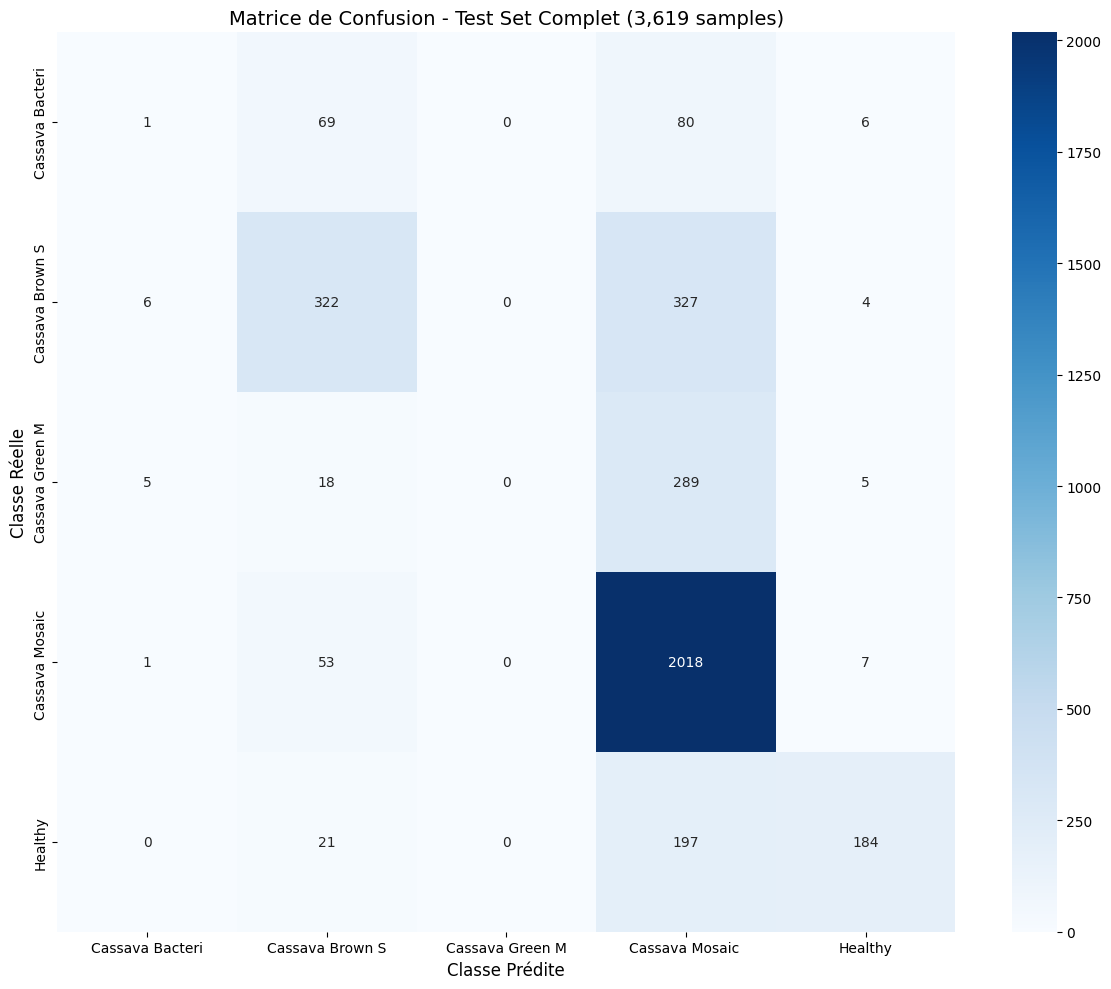

✅ Graphique accuracy sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage1_cassava_gemma3n_v2/accuracy_per_class_full_test.png


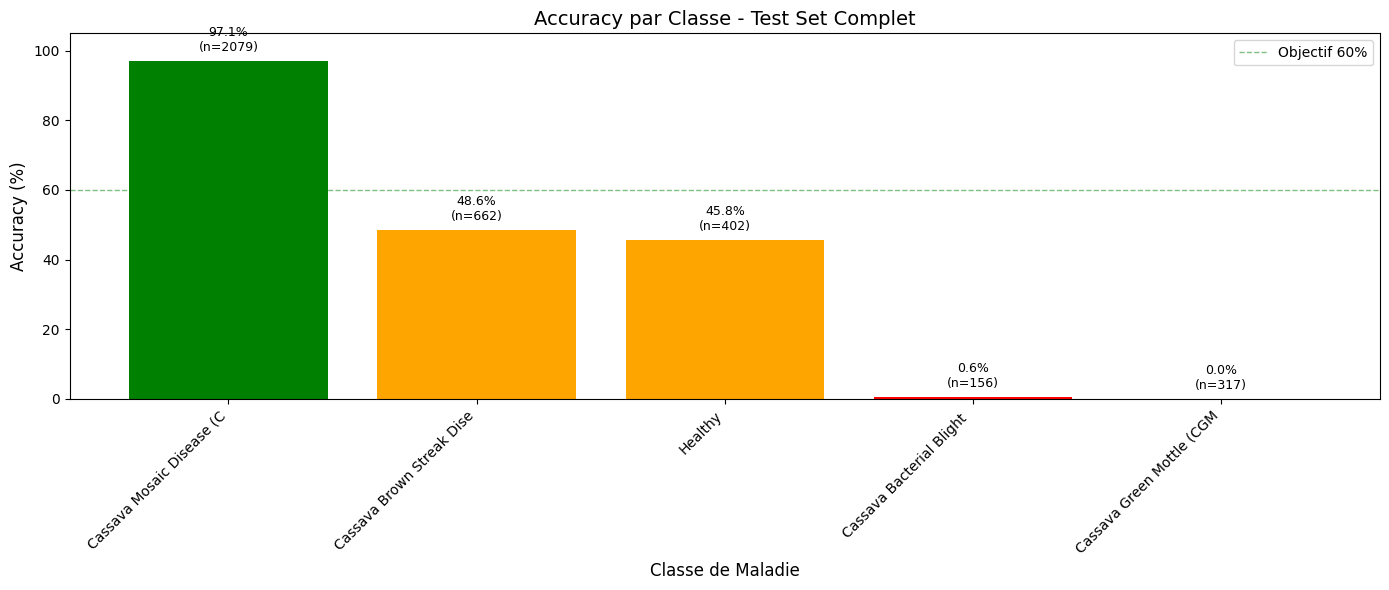


💾 SAUVEGARDE DES RÉSULTATS FINAUX
✅ Résultats sauvegardés: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage1_cassava_gemma3n_v2/final_test_results_full.json
✅ Erreurs détaillées sauvegardées: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage1_cassava_gemma3n_v2/test_errors_detailed.json

✅ STAGE 1 VALIDATION COMPLÈTE TERMINÉE


In [17]:
# =============================================================================
# VISUALISATIONS ET SAUVEGARDE
# =============================================================================

print(f"\n📊 GÉNÉRATION DES VISUALISATIONS")
print(f"{'='*80}")

# 1. Matrice de confusion en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[name[:15] for name in class_names],
    yticklabels=[name[:15] for name in class_names]
)
plt.title('Matrice de Confusion - Test Set Complet (3,619 samples)', fontsize=14)
plt.ylabel('Classe Réelle', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()

# Sauvegarder
confusion_matrix_path = CHECKPOINT_DIR / "confusion_matrix_full_test.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
print(f"✅ Matrice de confusion sauvegardée: {confusion_matrix_path}")
plt.show()

# 2. Accuracy par classe (bar plot)
plt.figure(figsize=(14, 6))
classes_sorted = sorted(class_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
class_names_sorted = [c[0][:25] for c in classes_sorted]
accuracies = [c[1]['accuracy'] for c in classes_sorted]
totals = [c[1]['total'] for c in classes_sorted]

bars = plt.bar(range(len(class_names_sorted)), accuracies, color=['green' if acc >= 60 else 'orange' if acc >= 40 else 'red' for acc in accuracies])
plt.xlabel('Classe de Maladie', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Accuracy par Classe - Test Set Complet', fontsize=14)
plt.xticks(range(len(class_names_sorted)), class_names_sorted, rotation=45, ha='right')
plt.ylim(0, 105)

# Ajouter les totaux sur les barres
for i, (bar, total) in enumerate(zip(bars, totals)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.1f}%\n(n={total})',
             ha='center', va='bottom', fontsize=9)

plt.axhline(y=60, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Objectif 60%')
plt.legend()
plt.tight_layout()

# Sauvegarder
accuracy_plot_path = CHECKPOINT_DIR / "accuracy_per_class_full_test.png"
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Graphique accuracy sauvegardé: {accuracy_plot_path}")
plt.show()

# =============================================================================
# SAUVEGARDE DES RÉSULTATS
# =============================================================================

print(f"\n💾 SAUVEGARDE DES RÉSULTATS FINAUX")
print(f"{'='*80}")

from datetime import datetime

# Créer dictionnaire complet des résultats
final_results = {
    "test_set_info": {
        "total_samples": total,
        "distribution": {name: count for name, count in class_counts.items()}
    },
    "global_metrics": {
        "accuracy": global_accuracy,
        "correct": correct,
        "total": total
    },
    "per_class_metrics": class_metrics,
    "confusion_matrix": cm.tolist(),
    "class_names": class_names,
    "training_info": {
        "model": "Gemma 3N-E2B-it",
        "lora_rank": 8,
        "learning_rate": 3e-5,
        "weight_decay": 0.1,
        "epochs": 2,
        "total_steps": 7320,
        "final_val_loss": 2.789,
        "final_train_loss": 0.0129
    },
    "prompt_used": CONSTRAINED_PROMPT,
    "timestamp": datetime.now().isoformat()
}

# Sauvegarder en JSON
results_path = CHECKPOINT_DIR / "final_test_results_full.json"
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

print(f"✅ Résultats sauvegardés: {results_path}")

# Sauvegarder aussi les erreurs détaillées
errors_path = CHECKPOINT_DIR / "test_errors_detailed.json"
with open(errors_path, 'w', encoding='utf-8') as f:
    json.dump(errors, f, indent=2, ensure_ascii=False)

print(f"✅ Erreurs détaillées sauvegardées: {errors_path}")

print(f"\n{'='*80}")
print("✅ STAGE 1 VALIDATION COMPLÈTE TERMINÉE")
print(f"{'='*80}")


In [18]:
# =============================================================================
# DÉCISION FINALE STAGE 1
# =============================================================================

print(f"\n{'='*80}")
print("DÉCISION FINALE - STAGE 1")
print(f"{'='*80}")

# Critères de succès
MIN_GLOBAL_ACCURACY = 60.0  # Objectif minimum
TARGET_GLOBAL_ACCURACY = 75.0  # Objectif cible
MIN_CLASS_ACCURACY = 30.0  # Minimum par classe

# Vérifications
success_criteria = {
    "global_accuracy": global_accuracy >= MIN_GLOBAL_ACCURACY,
    "no_zero_classes": all(m['accuracy'] > 0 for m in class_metrics.values()),
    "min_class_accuracy": all(m['accuracy'] >= MIN_CLASS_ACCURACY or m['total'] < 100
                               for m in class_metrics.values())
}

print(f"\n📋 VÉRIFICATION DES CRITÈRES")
print(f"{'='*80}")
print(f"  Global accuracy >= {MIN_GLOBAL_ACCURACY}%: {'✅' if success_criteria['global_accuracy'] else '❌'} ({global_accuracy:.2f}%)")
print(f"  Aucune classe à 0%: {'✅' if success_criteria['no_zero_classes'] else '❌'}")
print(f"  Classes >={MIN_CLASS_ACCURACY}%: {'✅' if success_criteria['min_class_accuracy'] else '❌'}")

# Décision finale
all_success = all(success_criteria.values())

print(f"\n{'='*80}")
if all_success:
    print("✅ ✅ ✅ STAGE 1 COMPLÈTEMENT VALIDÉ ! ✅ ✅ ✅")
    print(f"{'='*80}")
    print(f"\nAccuracy globale: {global_accuracy:.2f}% (objectif {MIN_GLOBAL_ACCURACY}% ✅)")
    print(f"\n🎯 RECOMMANDATION:")
    if global_accuracy >= TARGET_GLOBAL_ACCURACY:
        print(f"  → EXCELLENT ! Accuracy {global_accuracy:.2f}% >= {TARGET_GLOBAL_ACCURACY}%")
        print(f"  → Prêt pour PRODUCTION ou STAGE 2/4")
    else:
        print(f"  → BON ! Accuracy {global_accuracy:.2f}% >= {MIN_GLOBAL_ACCURACY}%")
        print(f"  → Peut passer au STAGE 2/4")
        print(f"  → Possibilité d'optimiser pour atteindre {TARGET_GLOBAL_ACCURACY}%")
else:
    print("⚠️  STAGE 1 PARTIELLEMENT VALIDÉ")
    print(f"{'='*80}")
    print(f"\nAccuracy globale: {global_accuracy:.2f}%")
    print(f"\n📋 AMÉLIORATIONS RECOMMANDÉES:")

    if not success_criteria['global_accuracy']:
        print(f"  ❌ Accuracy globale < {MIN_GLOBAL_ACCURACY}%")
        print(f"     → Besoin d'optimisation avant Stage 2")

    if not success_criteria['no_zero_classes']:
        zero_classes = [name for name, m in class_metrics.items() if m['accuracy'] == 0]
        print(f"  ❌ Classes à 0%: {', '.join(zero_classes)}")
        print(f"     → Data augmentation nécessaire")

    if not success_criteria['min_class_accuracy']:
        low_classes = [name for name, m in class_metrics.items()
                       if m['accuracy'] < MIN_CLASS_ACCURACY and m['total'] >= 100]
        print(f"  ⚠️  Classes < {MIN_CLASS_ACCURACY}%: {', '.join(low_classes)}")
        print(f"     → Class weighting ou focal loss recommandé")

print(f"\n{'='*80}")



DÉCISION FINALE - STAGE 1

📋 VÉRIFICATION DES CRITÈRES
  Global accuracy >= 60.0%: ✅ (69.83%)
  Aucune classe à 0%: ❌
  Classes >=30.0%: ❌

⚠️  STAGE 1 PARTIELLEMENT VALIDÉ

Accuracy globale: 69.83%

📋 AMÉLIORATIONS RECOMMANDÉES:
  ❌ Classes à 0%: Cassava Green Mottle (CGM)
     → Data augmentation nécessaire
  ⚠️  Classes < 30.0%: Cassava Bacterial Blight (CBB), Cassava Green Mottle (CGM)
     → Class weighting ou focal loss recommandé

